# Loan Approval Prediction using Classification Models

## Objective:
To build classification models that predict whether a loan application will be approved based on socio-economic and financial factors such as income, credit history, loan amount, and property area.

In [1]:
# Importing Required Libraries

# Basic Libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Evaluation Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

sns.set(style="whitegrid")

In [2]:
# Load Dataset

df = pd.read_csv(r"C:\Users\omhun\OneDrive\Documents\loan_prediction.csv")

# Display first 5 rows

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [3]:
# Check shape

df.shape

(614, 13)

In [4]:
# Checks Datatype

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [5]:
# Checks null values

df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [10]:
# Data Cleaning and Pre-processing

# Handle Missing Values

# For Numeric columns

df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median(), inplace=True)

# For Categorical Columns

df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
df['Married'].fillna(df['Married'].mode()[0], inplace=True)
df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace=True)
df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)

In [11]:
# Convert Categorical to Numeric

# Binary encoding

le = LabelEncoder()

df['Gender'] = le.fit_transform(df['Gender'])
df['Married'] = le.fit_transform(df['Married'])
df['Education'] = le.fit_transform(df['Education'])
df['Self_Employed'] = le.fit_transform(df['Self_Employed'])
df['Loan_Status'] = le.fit_transform(df['Loan_Status'])

# One-Hot encoding for multi-category

df = pd.get_dummies(df, columns=['Property_Area'], drop_first=True)

In [41]:
# Check class distribution

df['Loan_Status'].value_counts()

Loan_Status
1    422
0    192
Name: count, dtype: int64

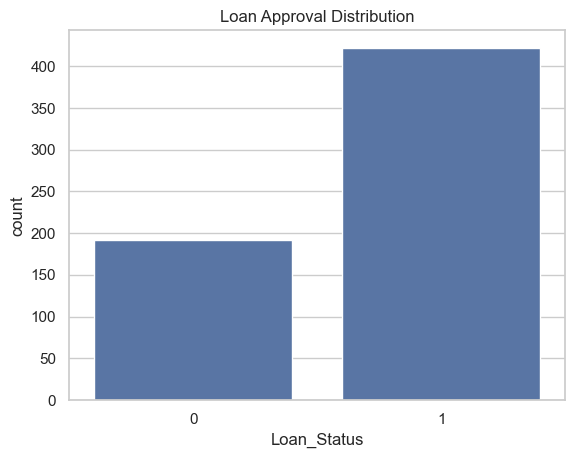

In [42]:
# Checks if dataset is imbalanced

sns.countplot(x='Loan_Status', data=df)
plt.title("Loan Approval Distribution")
plt.show()

<Figure size 600x500 with 0 Axes>

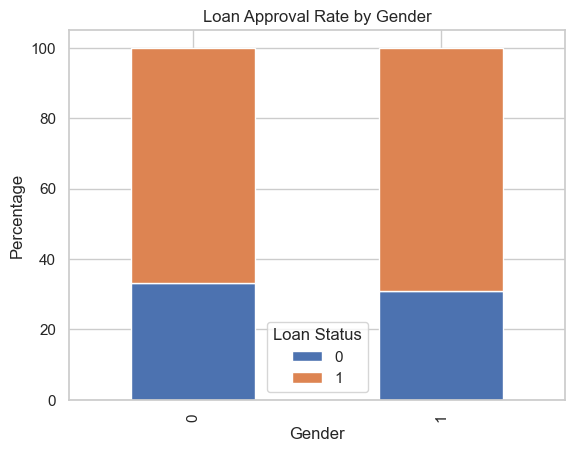

In [12]:
# Exploratory Data Analysis

# Visualization-1 : Approval Rate by Gender

plt.figure(figsize=(6,5))
approval_gender = pd.crosstab(df['Gender'], df['Loan_Status'], normalize='index') * 100
approval_gender.plot(kind='bar', stacked=True)
plt.title("Loan Approval Rate by Gender")
plt.ylabel("Percentage")
plt.legend(title="Loan Status")
plt.show()

# Insights:
## Loan approval rates are relatively similar across genders.
## Gender does not appear to be a strong standalone predictor of loan approval.

<Figure size 800x500 with 0 Axes>

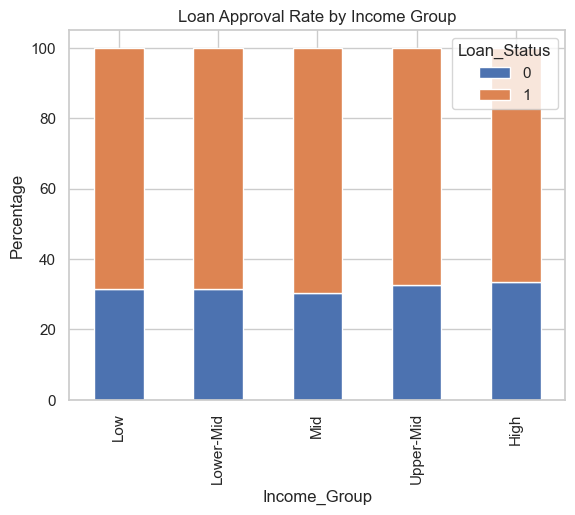

In [13]:
# Visualization-2 : Approval Rate by Income

# Create income category

df['Income_Group'] = pd.cut(df['ApplicantIncome'],
                            bins=[0,2500,5000,10000,20000,df['ApplicantIncome'].max()],
                            labels=['Low','Lower-Mid','Mid','Upper-Mid','High'])

# Plot for Approval rate by income group

plt.figure(figsize=(8,5))
approval_income = pd.crosstab(df['Income_Group'], df['Loan_Status'], normalize='index') * 100
approval_income.plot(kind='bar', stacked=True)
plt.title("Loan Approval Rate by Income Group")
plt.ylabel("Percentage")
plt.show()

# Insights:
## Higher income groups show slightly higher approval rates.
## However, income alone does not guarantee approval without strong credit history.

<Figure size 600x500 with 0 Axes>

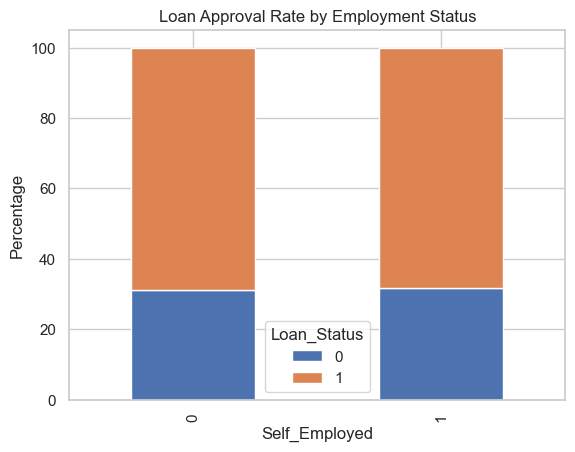

In [14]:
# Visualization-3 : Approval rate by Employement Status (using Self_Employed column)

plt.figure(figsize=(6,5))
approval_emp = pd.crosstab(df['Self_Employed'], df['Loan_Status'], normalize='index') * 100
approval_emp.plot(kind='bar', stacked=True)
plt.title("Loan Approval Rate by Employment Status")
plt.ylabel("Percentage")
plt.show()

# Insights:
## Employment status shows moderate influence on approval rates.
## Self-employed applicants may face slightly stricter approval patterns compared to salaried individuals.

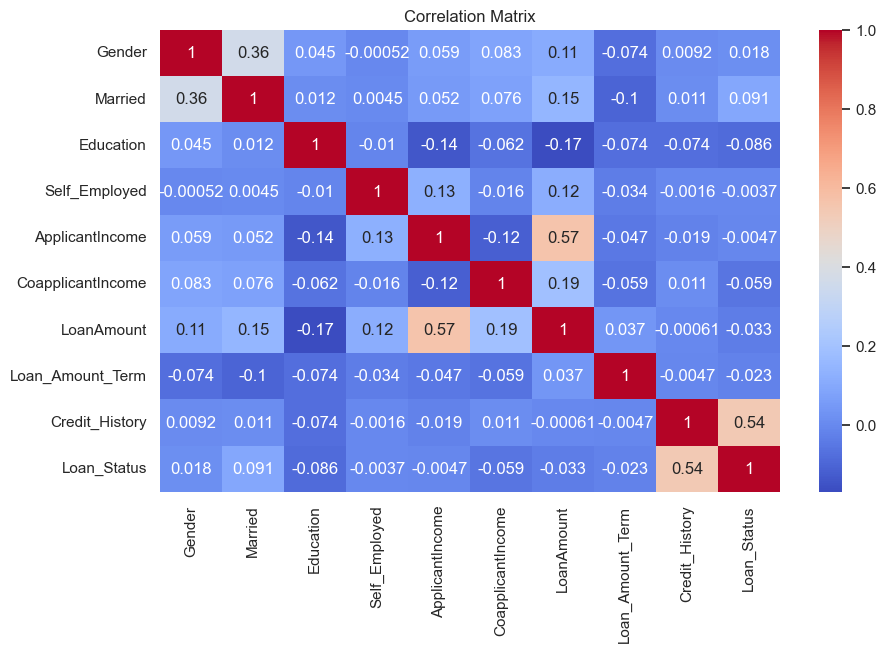

In [15]:
# Correlation Matrix (numerical features only)

plt.figure(figsize=(10,6))
numeric_df = df.select_dtypes(include=['int64','float64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# Insights:
# Credit_History shows strong positive correlation with Loan_Status.
# ApplicantIncome and LoanAmount have moderate relationships.
# Credit history appears to be the most important predictor.

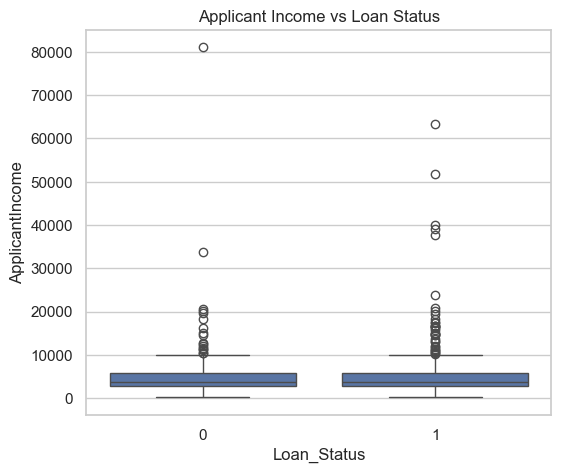

In [16]:
# Boxplots for numerical features

# Boxplot for Applicant income vs Loan status 

plt.figure(figsize=(6,5))
sns.boxplot(x='Loan_Status', y='ApplicantIncome', data=df)
plt.title("Applicant Income vs Loan Status")
plt.show()

# Insights:
## Approved applicants tend to have slightly higher median income.
## However, there is significant overlap between approved and rejected applicants.

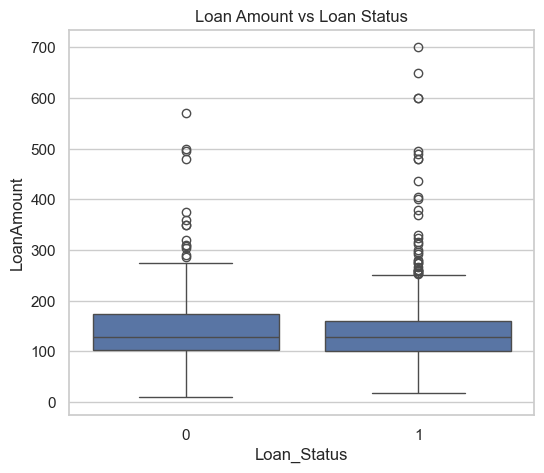

In [17]:
# Boxplot for loan amount vs loan status 

plt.figure(figsize=(6,5))
sns.boxplot(x='Loan_Status', y='LoanAmount', data=df)
plt.title("Loan Amount vs Loan Status")
plt.show()

# Insights:
## Higher loan amounts show slightly more rejection tendency.
## Moderate loan amounts have better approval rates.

In [24]:
# Prepare Data for Modelling

# Clean Dependents Column

df['Dependents'] = df['Dependents'].replace('3+', 3)
df['Dependents'] = df['Dependents'].astype(int)

In [28]:
# Remove Income_Group before modelling

df.drop('Income_Group', axis=1, inplace=True)

In [29]:
# Define X and y

X = df.drop(['Loan_Status', 'Loan_ID'], axis=1)
y = df['Loan_Status']

In [30]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [31]:
# Feature Scaling

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [32]:
# Model Building

# Logistic Regression

lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [33]:
# Decision Tree

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

In [34]:
# Random Forest

rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [35]:
# SVM

svm = SVC(probability=True)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

In [36]:
# Model Evaluation Function

def evaluate_model(y_test, y_pred):
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print("-"*40)

In [37]:
# Evaluate all

print("Logistic Regression")
evaluate_model(y_test, y_pred_lr)

print("Decision Tree")
evaluate_model(y_test, y_pred_dt)

print("Random Forest")
evaluate_model(y_test, y_pred_rf)

print("SVM")
evaluate_model(y_test, y_pred_svm)

Logistic Regression
Accuracy: 0.8617886178861789
Precision: 0.84
Recall: 0.9882352941176471
F1 Score: 0.9081081081081082
----------------------------------------
Decision Tree
Accuracy: 0.7560975609756098
Precision: 0.8235294117647058
Recall: 0.8235294117647058
F1 Score: 0.8235294117647058
----------------------------------------
Random Forest
Accuracy: 0.8292682926829268
Precision: 0.8478260869565217
Recall: 0.9176470588235294
F1 Score: 0.8813559322033898
----------------------------------------
SVM
Accuracy: 0.8536585365853658
Precision: 0.8316831683168316
Recall: 0.9882352941176471
F1 Score: 0.9032258064516129
----------------------------------------


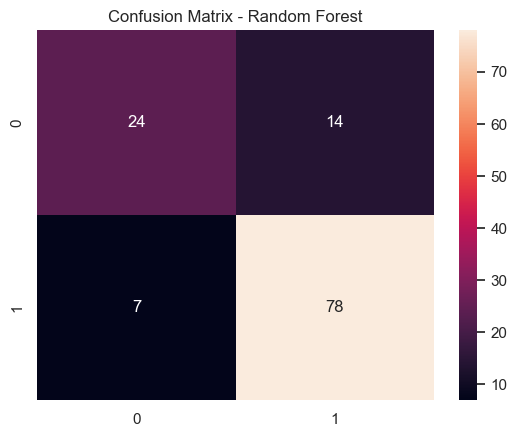

In [38]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Random Forest")
plt.show()

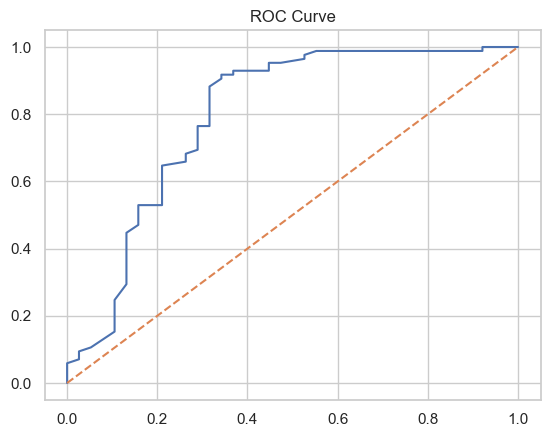

ROC-AUC Score: 0.7962848297213623


In [39]:
# ROC-AUC Curve

y_prob = rf.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.show()
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

## Insight for confusion matrix:

The confusion matrix shows that the model correctly classifies a majority of approved and rejected loan applications, indicating good overall predictive performance. However, some misclassifications exist, which suggests that certain borderline applications are harder for the model to distinguish.

## Insight for ROC-AUC curve:

The ROC curve demonstrates the model’s ability to effectively differentiate between approved and rejected applications across various thresholds. A high ROC-AUC score indicates strong classification performance and good separability between the two classes.

# Model Comparison:

Four classification models were trained and evaluated: Logistic Regression, Decision Tree, Random Forest, and Support Vector Machine (SVM).

- Logistic Regression provided a strong baseline performance and handled the binary classification problem effectively.
- Decision Tree captured non-linear relationships but showed signs of slight overfitting.
- Random Forest achieved the best overall performance due to its ensemble learning approach, reducing variance and improving generalization.
- SVM performed well in separating classes but required proper scaling and parameter tuning.

Based on Accuracy, Precision, Recall, F1 Score, and ROC-AUC evaluation, the Random Forest model emerged as the best-performing model for this dataset.

# How a Bank Would Use This Model in Practice

In a real-world scenario, a bank can integrate this loan approval prediction model into its loan processing system as a decision-support tool. When a customer submits a loan application, the applicant’s financial and personal details (such as income, credit history, loan amount, employment status, etc.) can be fed into the model to generate an approval probability score.

Based on this prediction, the bank can automatically classify applications into low-risk and high-risk categories. Low-risk applications can be fast-tracked for approval, reducing processing time, while high-risk applications can be flagged for detailed manual review by credit officers.

The model helps improve operational efficiency, reduce human bias in decision-making, and minimize the risk of loan defaults. Ultimately, it supports better credit risk management and enhances data-driven decision-making within the bank.

# Business Insights:

- Credit History is the most influential factor in loan approval decisions, showing strong correlation with the target variable.
- Applicants with higher and stable income levels generally show better approval rates.
- Employment status and property area moderately influence loan approval outcomes.
- The model can assist banks in automating preliminary loan screening processes.
- By reducing manual decision-making bias, the model can improve efficiency and consistency in loan approval evaluation.

# Conclusion:

This project successfully demonstrated the application of classification techniques to predict loan approval status based on socio-economic and financial features. Through systematic data preprocessing, exploratory data analysis, model building, and evaluation, meaningful insights were derived regarding the factors influencing loan decisions.

Among the models tested, Random Forest provided the most reliable predictive performance due to its ability to capture complex feature interactions. The developed model can serve as a decision-support tool for financial institutions to streamline loan approval processes and reduce credit risk.